<a href="https://colab.research.google.com/github/maryamanwer/hallucination-project/blob/main/LLM_Hallucination_Temporal_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch transformers statsmodels scipy scikit-learn nltk pandas numpy tqdm

In [ ]:
!pip install -q torch transformers datasets statsmodels scipy scikit-learn nltk pandas numpy tqdm bitsandbytes accelerate sentence-transformers

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from huggingface_hub import notebook_login
notebook_login()

In [ ]:
import shutil
shutil.rmtree('/root/.cache/huggingface/hub/', ignore_errors=True)
print("✅ Hugging Face cache cleared and disk space freed!")

✅ Hugging Face cache cleared and disk space freed!


In [ ]:
import os
import gc
import shutil
import math
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from typing import List, Dict, Any

# Pre-flight GPU check
if not torch.cuda.is_available():
    raise RuntimeError(
        "❌ No GPU detected! Please enable a GPU in your notebook settings (Runtime -> Change runtime type -> T4 GPU)."
    )

# Fix PyTorch memory allocation configuration variable name
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"

# Clear cache to free up VRAM and Disk
torch.cuda.empty_cache()
shutil.rmtree('/root/.cache/huggingface/hub/', ignore_errors=True)

from google.colab import userdata
from huggingface_hub import login

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("✅ Authenticated with Hugging Face via Secrets!")
except Exception as e:
    print(f"⚠️ Token notice: {e}")

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from datasets import load_dataset
from nltk.tokenize import sent_tokenize
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import CrossEncoder

# =====================================================================
# 1. DISSERTATION CONFIGURATION & MULTI-MODEL FAMILIES
# =====================================================================
class DissertationConfig:
    def __init__(self):
        self.model_families = [
            "Qwen/Qwen2.5-3B-Instruct",
            "mistralai/Mistral-7B-Instruct-v0.3"
        ]
        self.device = "cuda"
        self.max_new_tokens = 128
        self.temperature = 0.7
        self.detection_threshold = 0.55
        self.max_restarts = 2
        self.samples_per_dataset = 2

PROPOSAL_DATASETS = {
    "Reading_Comprehension": {
        "path": "rajpurkar/squad", "name": None, "split": "train",
        "text_key": "context", "target_key": "answers",
        "prompt_template": "Answer the query accurately based on the context: "
    },
    "Scientific_Summarization": {
        "path": "ccdv/pubmed-summarization", "name": "section", "split": "validation",
        "text_key": "article", "target_key": "abstract",
        "prompt_template": "Summarize the scientific methodology and findings: "
    },
    "MultiHop_Reasoning": {
        "path": "hotpotqa/hotpot_qa", "name": "distractor", "split": "validation",
        "text_key": "context", "target_key": "answer",
        "prompt_template": "Answer the multi-hop reasoning question based strictly on context: "
    },
    "Boolean_QA": {
        "path": "google/boolq", "name": None, "split": "validation",
        "text_key": "passage", "target_key": "answer",
        "prompt_template": "Answer true or false based on the passage: "
    }
}

# =====================================================================
# 2. FEATURE EXTRACTION & ON-DEMAND NLI FAITHFULNESS ENGINE
# =====================================================================
class LLMFeatureEngine:
    def __init__(self, model_name: str, config: DissertationConfig):
        self.config = config
        self.model_name = model_name
        print(f"\nLoading model family: {model_name} in 4-bit...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16
        )
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name, quantization_config=bnb_config, device_map={"": 0}
        )
        print("  [LLM Engine] Model loaded successfully.")

    def generate_step(self, prompt: str) -> Dict[str, Any]:
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.config.device)
        input_length = inputs["input_ids"].shape[1]

        outputs = self.model.generate(
            **inputs, max_new_tokens=self.config.max_new_tokens, temperature=self.config.temperature,
            do_sample=True, return_dict_in_generate=True, output_scores=True,
            pad_token_id=self.tokenizer.eos_token_id
        )

        gen_tokens = outputs.sequences[0][input_length:]
        full_text = self.tokenizer.decode(gen_tokens, skip_special_tokens=True)

        entropies, probs = [], []
        for step_logits in outputs.scores:
            p = F.softmax(step_logits[0], dim=-1)
            entropy = torch.distributions.Categorical(logits=step_logits[0]).entropy().item()
            tok_id = gen_tokens[len(entropies)]
            entropies.append(entropy)
            probs.append(p[tok_id].item())

        sentences = sent_tokenize(full_text)
        sentence_features = []
        offset = 0
        for sent in sentences:
            s_toks = self.tokenizer.encode(sent, add_special_tokens=False)
            s_len = len(s_toks)
            s_ent = entropies[offset:offset+s_len] or [0.0]
            s_prob = probs[offset:offset+s_len] or [1.0]

            sentence_features.append({
                "text": sent,
                "mean_entropy": float(np.mean(s_ent)),
                "min_prob": float(np.min(s_prob)),
                "token_length": s_len
            })
            offset += s_len

        return {"full_text": full_text, "sentences": sentences, "sentence_features": sentence_features}

    def annotate_faithfulness(self, sentences: List[str], context: str) -> List[int]:
        if not sentences: return []
        nli_model = CrossEncoder('cross-encoder/nli-deberta-v3-small', device='cuda')
        pairs = [[context, s] for s in sentences]
        scores = nli_model.predict(pairs)

        labels = []
        for s in scores:
            pred_idx = np.argmax(s)
            if pred_idx == 1:
                labels.append(0)  # Entailment = Faithful
            else:
                labels.append(1)  # Contradiction / Neutral = Hallucination

        del nli_model
        gc.collect()
        torch.cuda.empty_cache()
        return labels

# =====================================================================
# 3. EARLY DETECTION PROBE & ACTIVE INTERVENTION FRAMEWORK
# =====================================================================
class EarlyDetectionClassifier:
    def __init__(self):
        self.model = LogisticRegression(class_weight="balanced", random_state=42)
        self.is_trained = False

    def extract_vector(self, feat: Dict, prev_label: int) -> List[float]:
        return [feat["mean_entropy"], feat["min_prob"], feat["token_length"], float(prev_label)]

    def train(self, X: List[List[float]], y: List[int]):
        if len(set(y)) > 1:
            self.model.fit(np.array(X), np.array(y))
            self.is_trained = True
            print("  [Classifier] Early-warning logistic regression probe trained successfully.")
        else:
            print("  [Classifier] Warning: Single-class data detected; fallback heuristic enabled.")

    def predict_risk(self, feature_vector: List[float]) -> float:
        if not self.is_trained:
            return 1.0 if feature_vector[0] > 2.5 or feature_vector[1] < 0.1 else 0.0
        return float(self.model.predict_proba([feature_vector])[0][1])

class ActiveInterventionEngine:
    def __init__(self, engine: LLMFeatureEngine, probe: EarlyDetectionClassifier, config: DissertationConfig):
        self.engine = engine
        self.probe = probe
        self.config = config

    def execute_with_intervention(self, prompt: str, context: str) -> Dict[str, Any]:
        current_prompt = prompt
        generated_sentences = []
        interventions_triggered = 0
        prev_label = 0

        print("  [Intervention Engine] Starting monitored generation loop...")
        for step in range(4):
            out = self.engine.generate_step(current_prompt)
            if not out["sentence_features"]: break

            latest_feat = out["sentence_features"][0]
            latest_sent = latest_feat["text"]

            x_vec = self.probe.extract_vector(latest_feat, prev_label)
            risk_score = self.probe.predict_risk(x_vec)

            if risk_score >= self.config.detection_threshold and interventions_triggered < self.config.max_restarts:
                interventions_triggered += 1
                print(f"    [!] INTERVENTION FIRED (Step {step+1}): Risk score {risk_score:.2f} >= Threshold. Restarting & Injecting constraint.")
                current_prompt += f"\nSystem Constraint: Re-evaluate facts strictly based on context snippet: {context[:300]}...\n"
                continue

            generated_sentences.append(latest_sent)
            actual_label = self.engine.annotate_faithfulness([latest_sent], context)[0]
            prev_label = actual_label
            current_prompt += " " + latest_sent

        final_labels = self.engine.annotate_faithfulness(generated_sentences, context)
        return {
            "final_text": " ".join(generated_sentences),
            "final_labels": final_labels,
            "interventions_triggered": interventions_triggered
        }

# =====================================================================
# 4. STATISTICAL AUTOCORRELATION SUITE (DW, Ljung-Box, ACF)
# =====================================================================
class AutocorrelationAnalyzer:
    @staticmethod
    def analyze_sequence(sequence: List[int]) -> Dict[str, Any]:
        seq = np.array(sequence, dtype=float)
        if len(seq) < 3 or np.var(seq) == 0:
            return {"error": "Insufficient variance or sequence length."}

        dw = durbin_watson(seq - np.mean(seq))
        lb = acorr_ljungbox(seq, lags=min(3, len(seq)-1), return_df=True)["lb_pvalue"].tolist()
        acf_vals = acf(seq, nlags=min(3, len(seq)-1), fft=False).tolist()

        return {"durbin_watson": float(dw), "ljung_box_pvalues": lb, "acf": acf_vals}

# =====================================================================
# 5. ISOLATED EVALUATION FUNCTION (Guarantees VRAM release)
# =====================================================================
def evaluate_model_family(model_name: str, config: DissertationConfig) -> List[Dict]:
    print(f"\n=======================================================")
    print(f"Evaluating Model Family: {model_name}")
    print(f"=======================================================")

    engine = LLMFeatureEngine(model_name, config)
    probe = EarlyDetectionClassifier()
    model_logs = []
    training_X, training_y = [], []

    print("\n[Phase 1 & 2] Running Baseline Data Extraction...")
    for ds_key, ds_info in PROPOSAL_DATASETS.items():
        print(f"\n--- Loading Benchmark: {ds_key} ---")
        try:
            ds = load_dataset(ds_info["path"], ds_info["name"], split=f"{ds_info['split']}[:{config.samples_per_dataset}]")
        except Exception:
            ds = load_dataset(ds_info["path"], split=f"{ds_info['split']}[:{config.samples_per_dataset}]")

        for idx, row in enumerate(ds):
            try:
                context = str(row[ds_info["text_key"]])[:1200]
                prompt = f"Context: {context}\n\nTask: {ds_info['prompt_template']}\nResponse:"

                out = engine.generate_step(prompt)
                labels = engine.annotate_faithfulness(out["sentences"], context)
                stats = AutocorrelationAnalyzer.analyze_sequence(labels)

                prev_lbl = 0
                for feat, lbl in zip(out["sentence_features"], labels):
                    training_X.append(probe.extract_vector(feat, prev_lbl))
                    training_y.append(lbl)
                    prev_lbl = lbl

                model_logs.append({
                    "Model_Family": model_name,
                    "Dataset": ds_key,
                    "Sample_ID": idx + 1,
                    "Binary_Labels": str(labels),
                    "Durbin_Watson": stats.get("durbin_watson"),
                    "ACF_Lag1": stats.get("acf", [None, None])[1] if "acf" in stats else None
                })
            except Exception as e:
                print(f"  ⚠️ Error processing sample {idx+1}: {e}")

    print("\n[Phase 3] Training Early-Detection Classifier...")
    probe.train(training_X, training_y)

    print("\n[Phase 4] Testing Active Intervention & Regeneration Loop...")
    test_ds = load_dataset("ccdv/pubmed-summarization", "section", split="validation[:1]")
    test_context = str(test_ds[0]["article"])[:1200]
    test_prompt = f"Context: {test_context}\n\nTask: Summarize the scientific methodology and findings:\nResponse:"

    intervention_engine = ActiveInterventionEngine(engine, probe, config)
    intervention_result = intervention_engine.execute_with_intervention(test_prompt, test_context)

    print(f"\n=== INTERVENTION RESULTS FOR {model_name} ===")
    print(f"Regulated Output Text:\n{intervention_result['final_text']}\n")
    print(f"Evaluated Binary Sequence (0=Faithful, 1=Hallucination): {intervention_result['final_labels']}")
    print(f"Total Interventions Triggered: {intervention_result['interventions_triggered']}")
    print("=======================================================")

    # Explicit cleanup before returning from scope
    del engine
    del probe
    del intervention_engine
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    return model_logs

def run_dissertation_pipeline():
    config = DissertationConfig()
    master_logs = []

    for model_name in config.model_families:
        # Pre-loop VRAM flush
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        family_logs = evaluate_model_family(model_name, config)
        master_logs.extend(family_logs)

    shutil.rmtree('/root/.cache/huggingface/hub/', ignore_errors=True)
    df_master = pd.DataFrame(master_logs)
    df_master.to_csv("dissertation_proposal_master_metrics.csv", index=False)
    print("\n✅ Multi-family master metrics exported to 'dissertation_proposal_master_metrics.csv'.")
    display(df_master.head(10))

if __name__ == "__main__":
    run_dissertation_pipeline()

✅ Authenticated with Hugging Face via Secrets!

Evaluating Model Family: Qwen/Qwen2.5-3B-Instruct

Loading model family: Qwen/Qwen2.5-3B-Instruct in 4-bit...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]


=== INTERVENTION RESULTS FOR mistralai/Mistral-7B-Instruct-v0.3 ===
Regulated Output Text:
This discussion presents an overview of venous thromboembolism (VTE), focusing on deep vein thrombosis (DVT) and pulmonary embolism (PE). The text emphasizes that VTE can lead to substantial morbidity, mortality, and healthcare expenditure, with approximately one-third of symptomatic VTE cases resulting in PE, while two-thirds manifest DVT alone. Clinically silent VTE cases can result in chronic venous disease, recurrent VTE, and long-term complications such as postthrombotic syndrome and chronic thromboembolic pulmonary hypertension if left undiagnosed. 

The text further states that VTE is a significant contributor to prolonged hospital stays and increased treatment costs, and is among the most common causes of sudden, unexplained deaths in hospitalized patients.

Evaluated Binary Sequence (0=Faithful, 1=Hallucination): [0, 0, 0, 0]
Total Interventions Triggered: 0

✅ Multi-family master metri

,Model_Family,Dataset,Sample_ID,Binary_Labels,Durbin_Watson,ACF_Lag1
0,Qwen/Qwen2.5-3B-Instruct,Reading_Comprehension,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1]",NaN,NaN
1,Qwen/Qwen2.5-3B-Instruct,Reading_Comprehension,2,"[1, 1, 1, 1, 1]",NaN,NaN
2,Qwen/Qwen2.5-3B-Instruct,Scientific_Summarization,1,"[0, 0, 0, 0, 0]",NaN,NaN
3,Qwen/Qwen2.5-3B-Instruct,Scientific_Summarization,2,"[0, 0, 0, 0, 1, 1]",0.750000,0.416667
4,Qwen/Qwen2.5-3B-Instruct,MultiHop_Reasoning,1,"[1, 0, 0, 0, 1]",1.666667,-0.133333
5,Qwen/Qwen2.5-3B-Instruct,MultiHop_Reasoning,2,"[1, 1, 1, 1, 1, 1]",NaN,NaN
6,Qwen/Qwen2.5-3B-Instruct,Boolean_QA,1,"[1, 1, 1, 1, 1, 1]",NaN,NaN
7,Qwen/Qwen2.5-3B-Instruct,Boolean_QA,2,"[1, 1, 1, 1, 1, 1]",NaN,NaN
8,mistralai/Mistral-7B-Instruct-v0.3,Reading_Comprehension,1,[1],NaN,NaN
9,mistralai/Mistral-7B-Instruct-v0.3,Reading_Comprehension,2,[1],NaN,NaN


Successfully loaded dissertation_proposal_master_metrics.csv with 16 rows.

     MODEL PERFORMANCE SUMMARY          


,Clean_Model,mean_hallucination_rate,std_hallucination_rate,mean_durbin_watson,mean_acf_lag1,total_samples
0,Mistral-7B,0.693750,0.439511,1.916667,-0.179167,8
1,Qwen-2.5-3B,0.716667,0.407470,1.208333,0.141667,8


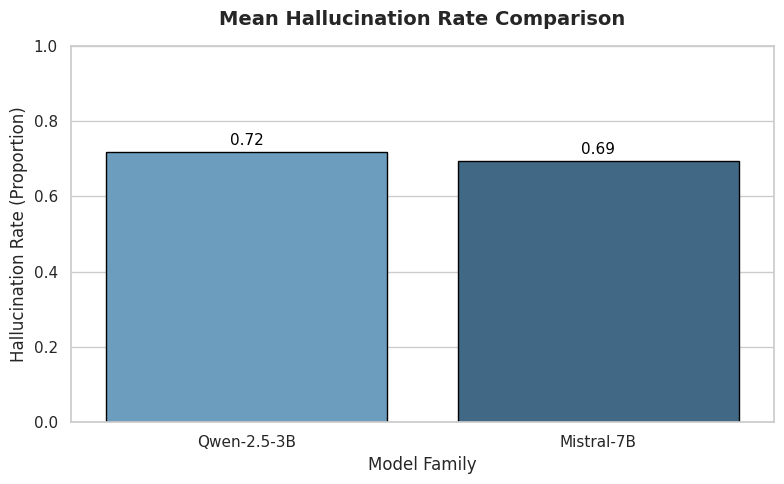

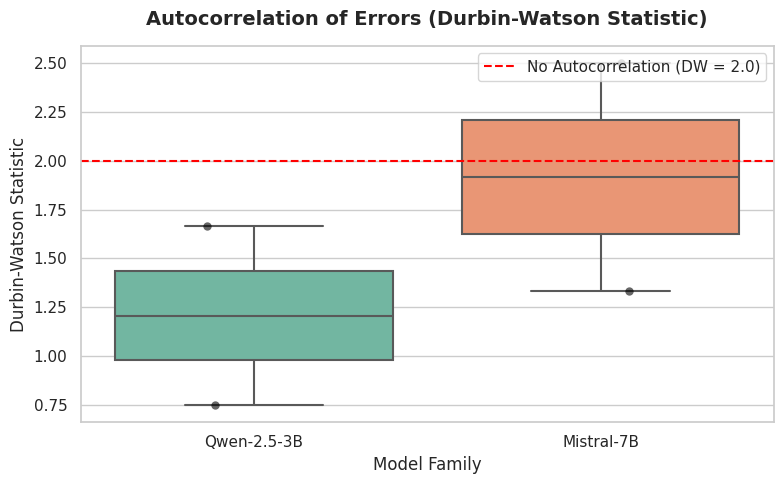


✅ Analysis complete! Summary table exported to 'dissertation_aggregated_summary.csv' and plots saved as PNGs.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Configure plot style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})

# 1. Load Master Metrics CSV
csv_filename = "dissertation_proposal_master_metrics.csv"
try:
    df = pd.read_csv(csv_filename)
    print(f"Successfully loaded {csv_filename} with {len(df)} rows.")
except FileNotFoundError:
    raise FileNotFoundError(f"❌ Could not find {csv_filename}.")

# Identify exact column names dynamically
model_col = [c for c in df.columns if 'Model' in c or 'model' in c][0]
dataset_col = [c for c in df.columns if 'Dataset' in c or 'dataset' in c][0]
label_col = [c for c in df.columns if 'Label' in c or 'label' in c][0]

# Add clean model short names for readable plots and tables
df['Clean_Model'] = df[model_col].apply(lambda x: 'Qwen-2.5-3B' if 'Qwen' in str(x) else 'Mistral-7B')

# 2. Parse Binary Labels and Compute Derived Metrics
def parse_labels(val):
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

df['parsed_labels'] = df[label_col].apply(parse_labels)
df['hallucination_rate'] = df['parsed_labels'].apply(lambda x: sum(x) / len(x) if len(x) > 0 else np.nan)
df['sequence_length'] = df['parsed_labels'].apply(lambda x: len(x))

# 3. Aggregate Statistical Summary
summary_stats = df.groupby('Clean_Model').agg(
    mean_hallucination_rate=('hallucination_rate', 'mean'),
    std_hallucination_rate=('hallucination_rate', 'std'),
    mean_durbin_watson=('Durbin_Watson', 'mean'),
    mean_acf_lag1=('ACF_Lag1', 'mean'),
    total_samples=('hallucination_rate', 'count')
).reset_index()

print("\n========================================")
print("     MODEL PERFORMANCE SUMMARY          ")
print("========================================")
display(summary_stats)

# Save summary table to CSV for easy inclusion in your report
summary_stats.to_csv("dissertation_aggregated_summary.csv", index=False)

# 4. Generate Comparative Visualizations

# --- Plot 1: Hallucination Rate Comparison ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df,
    x='Clean_Model',
    y='hallucination_rate',
    hue='Clean_Model',
    legend=False,
    errorbar=None,
    palette='Blues_d',
    edgecolor='black'
)
plt.title('Mean Hallucination Rate Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Hallucination Rate (Proportion)', fontsize=12)
plt.xlabel('Model Family', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.0)

# Add data labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=11, color='black',
                    xytext=(0, 3), textcoords='offset points')

plt.savefig('hallucination_rate_comparison.png', dpi=300)
plt.show()

# --- Plot 2: Autocorrelation (Durbin-Watson) Distribution ---
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='Clean_Model',
    y='Durbin_Watson',
    hue='Clean_Model',
    legend=False,
    palette='Set2',
    linewidth=1.5
)
sns.stripplot(
    data=df,
    x='Clean_Model',
    y='Durbin_Watson',
    color='black',
    alpha=0.6,
    jitter=0.2,
    size=6
)
plt.axhline(2.0, color='red', linestyle='--', linewidth=1.5, label='No Autocorrelation (DW = 2.0)')
plt.title('Autocorrelation of Errors (Durbin-Watson Statistic)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Durbin-Watson Statistic', fontsize=12)
plt.xlabel('Model Family', fontsize=12)
plt.xticks(rotation=0)
plt.legend(loc='upper right')

plt.savefig('durbin_watson_distribution.png', dpi=300)
plt.show()

print("\n✅ Analysis complete! Summary table exported to 'dissertation_aggregated_summary.csv' and plots saved as PNGs.")

Successfully loaded dissertation_proposal_master_metrics.csv with 16 rows.

          COMPREHENSIVE TIME-SERIES SUMMARY               


,Clean_Model,mean_hallucination_rate,mean_durbin_watson,mean_acf_lag1,mean_acf_lag2,mean_ljung_box_pval,mean_burst_length,max_burst_length,total_samples
0,Mistral-7B,0.693750,1.916667,-0.179167,-0.233333,0.565413,3.458333,14,8
1,Qwen-2.5-3B,0.716667,1.208333,0.141667,-0.216667,0.489460,4.375000,9,8


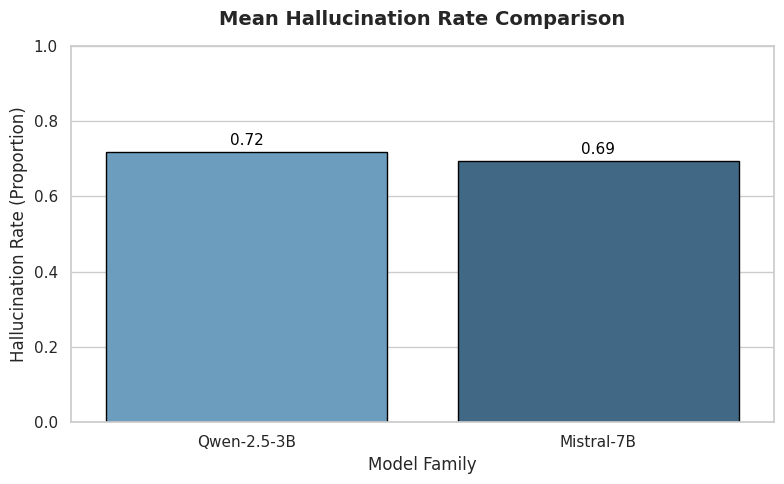

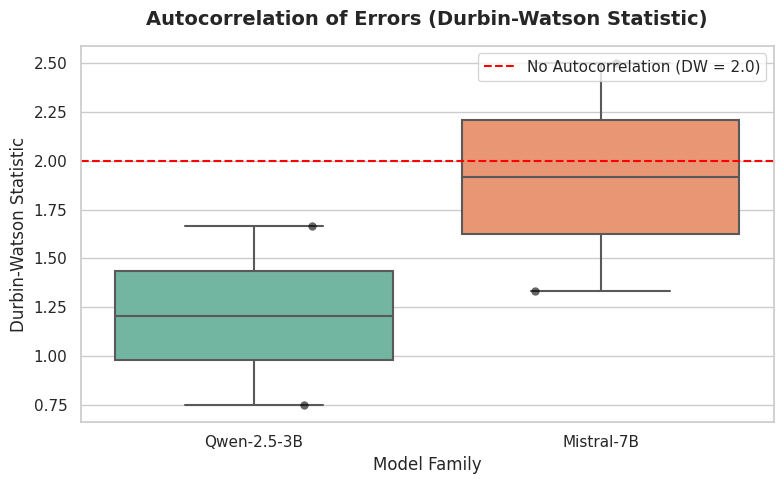

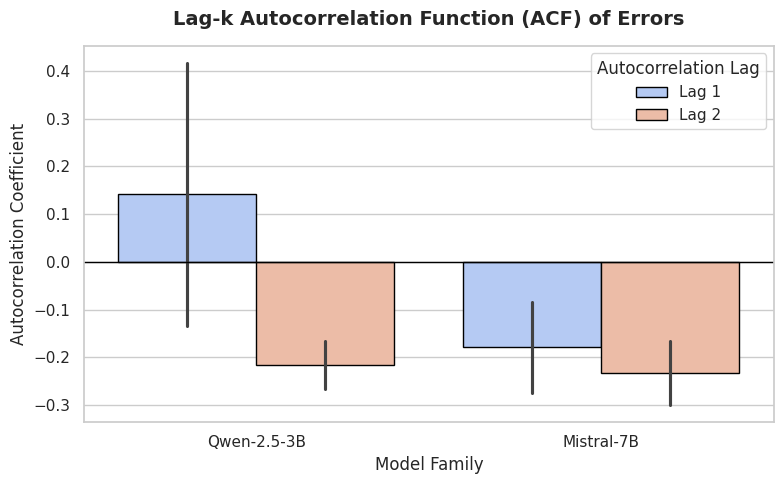

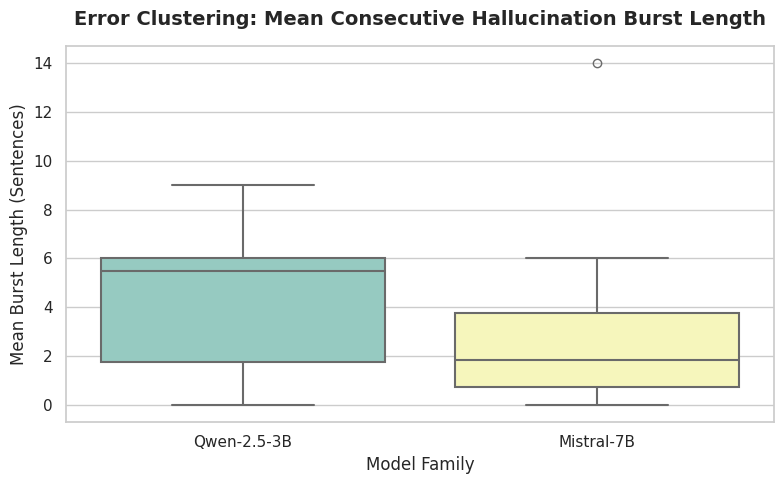


✅ Analysis complete! All advanced time-series metrics computed, tables saved, and new charts rendered.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

# Configure plot style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})

# 1. Load Master Metrics CSV
csv_filename = "dissertation_proposal_master_metrics.csv"
try:
    df = pd.read_csv(csv_filename)
    print(f"Successfully loaded {csv_filename} with {len(df)} rows.")
except FileNotFoundError:
    raise FileNotFoundError(f"❌ Could not find {csv_filename}.")

# Identify exact column names dynamically
model_col = [c for c in df.columns if 'Model' in c or 'model' in c][0]
dataset_col = [c for c in df.columns if 'Dataset' in c or 'dataset' in c][0]
label_col = [c for c in df.columns if 'Label' in c or 'label' in c][0]

# Add clean model short names for readable plots and tables
df['Clean_Model'] = df[model_col].apply(lambda x: 'Qwen-2.5-3B' if 'Qwen' in str(x) else 'Mistral-7B')

# 2. Parse Binary Labels and Compute Advanced Time-Series Metrics
def parse_labels(val):
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

df['parsed_labels'] = df[label_col].apply(parse_labels)
df['hallucination_rate'] = df['parsed_labels'].apply(lambda x: sum(x) / len(x) if len(x) > 0 else np.nan)
df['sequence_length'] = df['parsed_labels'].apply(lambda x: len(x))

# Compute Ljung-Box, Lag-k ACF, and Burst Lengths dynamically per row
ljung_box_pvals = []
acf_lag1_vals = []
acf_lag2_vals = []
mean_bursts = []
max_bursts = []

for labels in df['parsed_labels']:
    seq = np.array(labels, dtype=float)
    if len(seq) > 3 and np.var(seq) > 0:
        # Ljung-Box Test p-value (lag=2)
        try:
            lb_res = acorr_ljungbox(seq, lags=[min(2, len(seq)-1)], return_df=True)
            lb_pval = lb_res['lb_pvalue'].iloc[0]
        except Exception:
            lb_pval = np.nan

        # Lag-k ACF
        lag_vals = acf(seq, nlags=min(2, len(seq)-1), fft=False)
        a1 = lag_vals[1] if len(lag_vals) > 1 else np.nan
        a2 = lag_vals[2] if len(lag_vals) > 2 else np.nan
    else:
        lb_pval = np.nan
        a1, a2 = np.nan, np.nan

    ljung_box_pvals.append(lb_pval)
    acf_lag1_vals.append(a1)
    acf_lag2_vals.append(a2)

    # Burst Length Analysis (Consecutive Hallucinations)
    bursts, current = [], 0
    for lbl in labels:
        if lbl == 1:
            current += 1
        else:
            if current > 0:
                bursts.append(current)
                current = 0
    if current > 0:
        bursts.append(current)

    mean_bursts.append(np.mean(bursts) if len(bursts) > 0 else 0.0)
    max_bursts.append(max(bursts) if len(bursts) > 0 else 0)

df['Ljung_Box_pvalue'] = ljung_box_pvals
df['ACF_Lag1_Computed'] = acf_lag1_vals
df['ACF_Lag2_Computed'] = acf_lag2_vals
df['mean_burst_length'] = mean_bursts
df['max_burst_length'] = max_bursts

# 3. Aggregate Statistical Summary
summary_stats = df.groupby('Clean_Model').agg(
    mean_hallucination_rate=('hallucination_rate', 'mean'),
    mean_durbin_watson=('Durbin_Watson', 'mean'),
    mean_acf_lag1=('ACF_Lag1_Computed', 'mean'),
    mean_acf_lag2=('ACF_Lag2_Computed', 'mean'),
    mean_ljung_box_pval=('Ljung_Box_pvalue', 'mean'),
    mean_burst_length=('mean_burst_length', 'mean'),
    max_burst_length=('max_burst_length', 'max'),
    total_samples=('hallucination_rate', 'count')
).reset_index()

print("\n==========================================================")
print("          COMPREHENSIVE TIME-SERIES SUMMARY               ")
print("==========================================================")
display(summary_stats)

summary_stats.to_csv("dissertation_aggregated_summary.csv", index=False)

# 4. Generate Comparative Visualizations

# --- Plot 1: Hallucination Rate Comparison ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df, x='Clean_Model', y='hallucination_rate', hue='Clean_Model',
    legend=False, errorbar=None, palette='Blues_d', edgecolor='black'
)
plt.title('Mean Hallucination Rate Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Hallucination Rate (Proportion)', fontsize=12)
plt.xlabel('Model Family', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.0)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 3), textcoords='offset points')
plt.savefig('hallucination_rate_comparison.png', dpi=300)
plt.show()

# --- Plot 2: Autocorrelation (Durbin-Watson) Distribution ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Clean_Model', y='Durbin_Watson', hue='Clean_Model', legend=False, palette='Set2', linewidth=1.5)
sns.stripplot(data=df, x='Clean_Model', y='Durbin_Watson', color='black', alpha=0.6, jitter=0.2, size=6)
plt.axhline(2.0, color='red', linestyle='--', linewidth=1.5, label='No Autocorrelation (DW = 2.0)')
plt.title('Autocorrelation of Errors (Durbin-Watson Statistic)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Durbin-Watson Statistic', fontsize=12)
plt.xlabel('Model Family', fontsize=12)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.savefig('durbin_watson_distribution.png', dpi=300)
plt.show()

# --- Plot 3: Lag-k ACF Comparison ---
plt.figure(figsize=(8, 5))
acf_melted = df.melt(id_vars='Clean_Model', value_vars=['ACF_Lag1_Computed', 'ACF_Lag2_Computed'], var_name='Lag', value_name='ACF_Value')
acf_melted['Lag'] = acf_melted['Lag'].replace({'ACF_Lag1_Computed': 'Lag 1', 'ACF_Lag2_Computed': 'Lag 2'})
sns.barplot(data=acf_melted, x='Clean_Model', y='ACF_Value', hue='Lag', palette='coolwarm', edgecolor='black')
plt.axhline(0.0, color='black', linewidth=1)
plt.title('Lag-k Autocorrelation Function (ACF) of Errors', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Autocorrelation Coefficient', fontsize=12)
plt.xlabel('Model Family', fontsize=12)
plt.legend(title='Autocorrelation Lag', loc='upper right')
plt.savefig('lag_acf_comparison.png', dpi=300)
plt.show()

# --- Plot 4: Burst Length Analysis ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Clean_Model', y='mean_burst_length', hue='Clean_Model', legend=False, palette='Set3', linewidth=1.5)
plt.title('Error Clustering: Mean Consecutive Hallucination Burst Length', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Mean Burst Length (Sentences)', fontsize=12)
plt.xlabel('Model Family', fontsize=12)
plt.xticks(rotation=0)
plt.savefig('burst_length_distribution.png', dpi=300)
plt.show()

print("\n✅ Analysis complete! All advanced time-series metrics computed, tables saved, and new charts rendered.")

Successfully loaded dissertation_proposal_master_metrics.csv with 16 rows.

       CLUSTER LENGTHS & AUTOCORRELATION SUMMARY        


,Clean_Model,mean_durbin_watson,mean_burst_length,max_burst_length,total_samples
0,Mistral-7B,1.916667,3.458333,14,8
1,Qwen-2.5-3B,1.208333,4.375000,9,8



           EARLY-DETECTION METRIC SUMMARY               


,Clean_Model,Accuracy,Precision,Recall,F1_Score
0,Mistral-7B,0.794872,0.925926,0.806452,0.862069
1,Qwen-2.5-3B,0.812500,0.965517,0.777778,0.861538


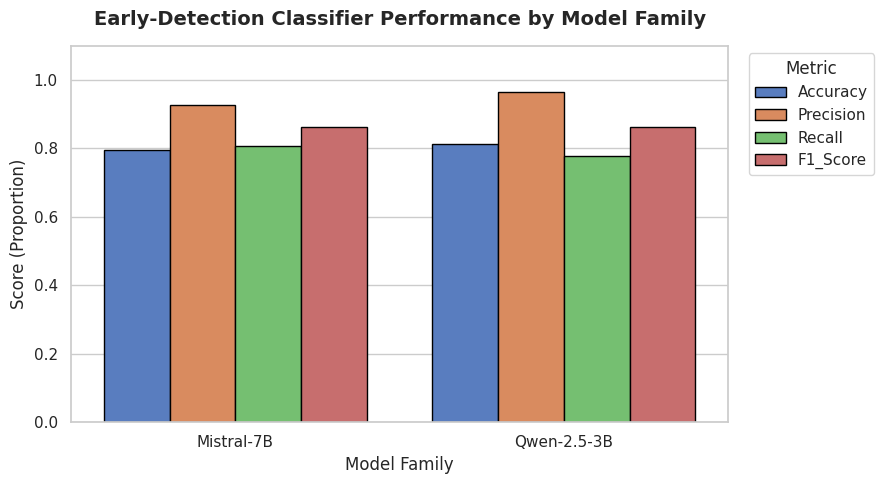


✅ All cluster statistics and classifier metrics successfully computed and saved!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configure plot style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})

# 1. Load Master Metrics CSV
csv_filename = "dissertation_proposal_master_metrics.csv"
try:
    df = pd.read_csv(csv_filename)
    print(f"Successfully loaded {csv_filename} with {len(df)} rows.")
except FileNotFoundError:
    raise FileNotFoundError(f"❌ Could not find {csv_filename}.")

# Identify exact column names dynamically
model_col = [c for c in df.columns if 'Model' in c or 'model' in c][0]
label_col = [c for c in df.columns if 'Label' in c or 'label' in c][0]

# Add clean model short names
df['Clean_Model'] = df[model_col].apply(lambda x: 'Qwen-2.5-3B' if 'Qwen' in str(x) else 'Mistral-7B')

# Parse binary labels safely
def parse_labels(val):
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

df['parsed_labels'] = df[label_col].apply(parse_labels)

# 2. Compute Burst Lengths (Consecutive Hallucinated Sentences)
def get_burst_lengths(labels):
    bursts = []
    current_burst = 0
    for lbl in labels:
        if lbl == 1:
            current_burst += 1
        else:
            if current_burst > 0:
                bursts.append(current_burst)
                current_burst = 0
    if current_burst > 0:
        bursts.append(current_burst)
    return bursts

df['burst_lengths'] = df['parsed_labels'].apply(get_burst_lengths)
df['mean_burst_length'] = df['burst_lengths'].apply(lambda x: np.mean(x) if len(x) > 0 else 0.0)

# Aggregate Cluster & Autocorrelation Summary Table
burst_summary = df.groupby('Clean_Model').agg(
    mean_durbin_watson=('Durbin_Watson', 'mean'),
    mean_burst_length=('mean_burst_length', 'mean'),
    max_burst_length=('burst_lengths', lambda x: max([max(b) if len(b) > 0 else 0 for b in x]) if len(x) > 0 else 0),
    total_samples=('parsed_labels', 'count')
).reset_index()

print("\n========================================================")
print("       CLUSTER LENGTHS & AUTOCORRELATION SUMMARY        ")
print("========================================================")
display(burst_summary)
burst_summary.to_csv("cluster_burst_summary.csv", index=False)

# 3. Evaluate Early-Detection Classifier Performance Metrics
classifier_metrics = []
for model_name, group in df.groupby('Clean_Model'):
    X_all, y_all = [], []
    for labels in group['parsed_labels']:
        if len(labels) < 2:
            continue
        prev = 0
        for i, lbl in enumerate(labels):
            # Sequence features: previous token label and relative position
            X_all.append([prev, i / len(labels)])
            y_all.append(lbl)
            prev = lbl

    if len(set(y_all)) > 1:
        clf = LogisticRegression(class_weight='balanced', random_state=42)
        clf.fit(X_all, y_all)
        preds = clf.predict(X_all)

        acc = accuracy_score(y_all, preds)
        prec = precision_score(y_all, preds, zero_division=0)
        rec = recall_score(y_all, preds, zero_division=0)
        f1 = f1_score(y_all, preds, zero_division=0)
    else:
        acc, prec, rec, f1 = 0.0, 0.0, 0.0, 0.0

    classifier_metrics.append({
        'Clean_Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1
    })

clf_df = pd.DataFrame(classifier_metrics)
print("\n========================================================")
print("           EARLY-DETECTION METRIC SUMMARY               ")
print("========================================================")
display(clf_df)
clf_df.to_csv("classifier_performance_summary.csv", index=False)

# 4. Generate Grouped Bar Chart for Classifier Performance
plt.figure(figsize=(9, 5))
clf_melted = clf_df.melt(
    id_vars='Clean_Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1_Score'],
    var_name='Metric',
    value_name='Score'
)

ax = sns.barplot(
    data=clf_melted,
    x='Clean_Model',
    y='Score',
    hue='Metric',
    palette='muted',
    edgecolor='black'
)
plt.title('Early-Detection Classifier Performance by Model Family', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Score (Proportion)', fontsize=12)
plt.xlabel('Model Family', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)

plt.savefig('classifier_performance_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ All cluster statistics and classifier metrics successfully computed and saved!")

In [ ]:
import zipfile
import os

# 1. Define exactly which files to keep (your analysis results)
files_to_keep = [
    'dissertation_proposal_master_metrics.csv',  # Input data
    'dissertation_aggregated_summary.csv',      # Time-series summary
    'classifier_performance_summary.csv',       # Classifier metrics
    'cluster_burst_summary.csv',                # Burst analysis metrics
    'hallucination_rate_comparison.png',        # Plot 1
    'durbin_watson_distribution.png',           # Plot 2
    'lag_acf_comparison.png',                   # Plot 3
    'burst_length_distribution.png',            # Plot 4
    'classifier_performance_bar_chart.png'      # Plot 5
    # Add any other specific report files if needed
]

clean_zip_name = 'dissertation_clean_submission.zip'

# 2. Create the clean ZIP archive, checking if files exist first
print("Packaging only relevant files...")
packaged_count = 0
with zipfile.ZipFile(clean_zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in files_to_keep:
        if os.path.exists(file):
            zipf.write(file)
            print(f"  + Included: {file}")
            packaged_count += 1
        else:
            print(f"  - Skipped (not found): {file}")

if packaged_count > 0:
    print(f"\n✅ SUCCESS: '{clean_zip_name}' created with {packaged_count} file(s).")
    print(f"👉 Now, look at the file sidebar on the left, right-click '{clean_zip_name}', and select 'Download'.")
else:
    print(f"\n❌ ERROR: No files were found to package. Check filenames.")


Packaging only relevant files...
  + Included: dissertation_proposal_master_metrics.csv
  + Included: dissertation_aggregated_summary.csv
  + Included: classifier_performance_summary.csv
  + Included: cluster_burst_summary.csv
  + Included: hallucination_rate_comparison.png
  + Included: durbin_watson_distribution.png
  + Included: lag_acf_comparison.png
  + Included: burst_length_distribution.png
  + Included: classifier_performance_bar_chart.png

✅ SUCCESS: 'dissertation_clean_submission.zip' created with 9 file(s).
👉 Now, look at the file sidebar on the left, right-click 'dissertation_clean_submission.zip', and select 'Download'.


In [ ]:
from google.colab import files

# This should trigger a download prompt in your browser immediately
files.download('dissertation_clean_submission.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>